# Тестирование десктоп-приложения: Telegram Desktop

Домашнее задание к уроку «Тестирование десктоп-приложений» (VK Education, ручное тестирование).

Telegram Desktop — нативное приложение на Qt, один код для Windows, macOS и Linux. Чек-лист построен по темам урока: сеть, режимы компьютера, экран и окно, мышь и клавиатура, оперативная память. Данные — в `telegram_desktop_testing.xlsx`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

FILE = 'telegram_desktop_testing.xlsx'
raw = pd.read_excel(FILE, sheet_name='Чек-лист', keep_default_na=False, na_values=[''])
is_section = raw['Проверка'].isna()
raw['Раздел'] = raw['ID'].where(is_section).ffill()
checklist = raw[~is_section].copy()
print(f'Проверок: {len(checklist)}')
checklist['Результат'].value_counts()

Проверок: 34


Результат
Pass          31
Наблюдение     2
N/A            1
Name: count, dtype: int64

## 1. Результаты по разделам

In [2]:
order = ['Pass', 'Наблюдение', 'Fail', 'N/A']
summary = pd.crosstab(checklist['Раздел'], checklist['Результат']).reindex(columns=order, fill_value=0)
summary

Результат,Pass,Наблюдение,Fail,N/A
Раздел,,,,
Мышь и клавиатура,3,1,0,0
Основные функции,6,0,0,0
Работа с сетью,5,0,0,0
Режимы компьютера,5,0,0,0
Ресурсы,2,1,0,1
"Установка, запуск, обновление",4,0,0,0
Экран и окно,6,0,0,0


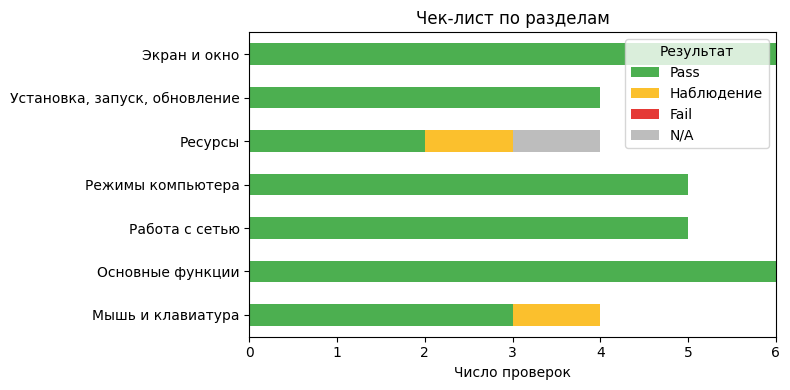

In [3]:
ax = summary.plot.barh(stacked=True, color=['#4CAF50', '#FBC02D', '#E53935', '#BDBDBD'], figsize=(8, 4))
ax.set_xlabel('Число проверок'); ax.set_ylabel(''); ax.set_title('Чек-лист по разделам')
plt.tight_layout(); plt.show()

## 2. Замер памяти (TC-08)

Значения из диспетчера задач Windows.

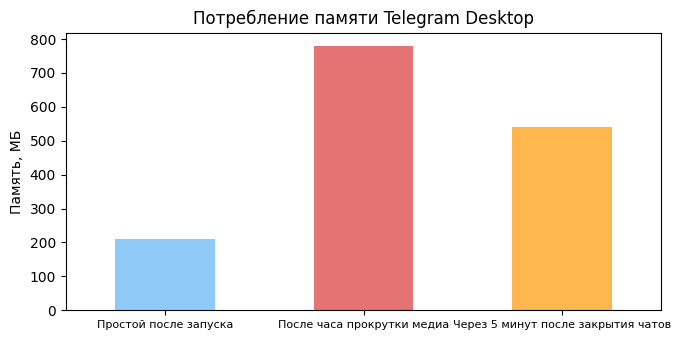

После закрытия чатов память выше стартовой в 2.6 раза


In [4]:
memory = pd.Series({'Простой после запуска': 210, 'После часа прокрутки медиа': 780, 'Через 5 минут после закрытия чатов': 540}, name='МБ')
ax = memory.plot.bar(color=['#90CAF9', '#E57373', '#FFB74D'], figsize=(7, 3.5))
ax.set_ylabel('Память, МБ'); ax.set_title('Потребление памяти Telegram Desktop'); plt.xticks(rotation=0, fontsize=8)
plt.tight_layout(); plt.show()
print(f'После закрытия чатов память выше стартовой в {memory.iloc[2] / memory.iloc[0]:.1f} раза')

## 3. Наблюдения

In [5]:
pd.read_excel(FILE, sheet_name='Наблюдения')[['ID', 'Заголовок', 'Приоритет']]

,ID,Заголовок,Приоритет
0,OBS-01,Память после долгой работы с медиа освобождает...,Низкий
1,OBS-02,Неочевидная навигация с клавиатуры,Низкий


## Вывод

Дефектов не найдено: приложение устойчиво работает без сети, после сна и гибернации, в трее, при смене размера окна, масштаба и мониторов. Два наблюдения — неполное освобождение памяти после работы с медиа (нужен повторный замер, чтобы отличить кэш от утечки) и неочевидная навигация с клавиатуры. macOS и Linux не проверены.